In [156]:
import numpy as np
import pandas as pd
from arch import arch_model

# Load Excel
df = pd.read_excel("Pro3_Stage1_SP25.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# === Core Features (Already Included) ===
df['SMA_10'] = df['Price'].rolling(window=10).mean()
df['EMA_10'] = df['Price'].ewm(span=10, adjust=False).mean()

delta = df['Price'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Price'].ewm(span=12, adjust=False).mean()
ema_26 = df['Price'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

rolling_mean = df['Price'].rolling(window=20).mean()
rolling_std = df['Price'].rolling(window=20).std()
df['BB_upper'] = rolling_mean + 2 * rolling_std
df['BB_lower'] = rolling_mean - 2 * rolling_std

# === New Features ===
# ATR (14)
df['ATR_14'] = df['Price'].rolling(window=14).apply(lambda x: np.max(x) - np.min(x))

# Stochastic Oscillator (14)
low_14 = df['Price'].rolling(window=14).min()
high_14 = df['Price'].rolling(window=14).max()
df['Stochastic_14'] = 100 * ((df['Price'] - low_14) / (high_14 - low_14))

# Rate of Change (ROC, 14)
df['ROC_14'] = df['Price'].pct_change(periods=14) * 100

# Exponential Weighted Moving Average (EWMA, 14)
df['EWMA_14'] = df['Price'].ewm(span=14, adjust=False).mean()

# GARCH (Volatility, 14)
returns = df['Price'].pct_change().dropna()
garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_fitted = garch_model.fit(disp='off')
df['GARCH_14'] = np.nan
df.loc[returns.index, 'GARCH_14'] = garch_fitted.conditional_volatility

# Price Change and Log Return (Already Included)
df['Price_Change'] = df['Price'].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
df['Log_Return'] = np.log(df['Price'] / df['Price'].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)

# Prediction target: next day's price
df['Target'] = df['Price'].shift(-1)
# Drop any rows with NaNs
df.dropna(inplace=True)

# === Prepare Features and Target ===
features = ['SMA_10', 'EMA_10', 'RSI_14', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 
            'ATR_14', 'Stochastic_14', 'ROC_14', 'EWMA_14', 'GARCH_14', 'Price_Change', 'Log_Return']

X = df[features].to_numpy()
y = df['Target'].to_numpy()

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

df


Features Shape: (1015, 14)
Target Shape: (1015,)


/Users/johnfeng/Library/Python/3.9/lib/python/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001421. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




,Price,SMA_10,EMA_10,RSI_14,MACD,MACD_signal,BB_upper,BB_lower,ATR_14,Stochastic_14,ROC_14,EWMA_14,GARCH_14,Price_Change,Log_Return,Target
Date,,,,,,,,,,,,,,,,
2022-01-20,48.773,50.8081,50.911313,33.975122,-1.787984,-1.631818,60.341667,45.331533,4.286,2.636491,-10.833836,51.514239,0.034772,-0.021487,-0.021721,47.323
2022-01-21,47.323,50.6744,50.258892,34.541156,-1.965990,-1.698653,59.883129,44.773271,5.526,0.000000,-10.620255,50.955407,0.034343,-0.029730,-0.030180,40.182
2022-01-22,40.182,49.6169,48.426730,28.412483,-2.652702,-1.889463,60.048764,42.725436,12.667,0.000000,-19.196429,49.518953,0.034267,-0.150899,-0.163577,37.900
2022-01-23,37.900,48.1220,46.512779,26.776352,-3.342533,-2.180077,60.005583,40.598517,14.949,0.000000,-22.331291,47.969759,0.047777,-0.056792,-0.058468,39.920
2022-01-24,39.920,47.0235,45.314092,30.497229,-3.683769,-2.480815,59.350514,39.405586,14.949,13.512610,-19.452796,46.896458,0.048182,0.053298,0.051926,39.209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-26,54.134,56.6001,55.766700,57.194372,0.902863,1.024528,59.788977,49.527223,6.137,24.621150,3.906025,55.531735,0.027762,-0.035852,-0.036511,55.016
2024-10-27,55.016,56.4358,55.630209,57.287992,0.784460,0.976515,59.806393,49.777607,6.137,38.992993,3.901794,55.462971,0.028552,0.016293,0.016162,55.787
2024-10-28,55.787,56.3725,55.658717,60.822274,0.744258,0.930063,59.828096,50.143404,4.626,35.732815,6.012580,55.506174,0.028239,0.014014,0.013917,57.292


# RF

In [157]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from math import sqrt

# Use full in-sample data
X_in_sample = X
y_in_sample = y

# Sliding window setup
window_size = 5
train_ratio = 0.8
rf_predictions = []
rf_true = []

# Trim to match RNN length (1007)
target_length = 1007
start_index = len(X_in_sample) - target_length

for i in range(start_index, len(X_in_sample)):
    # Calculate the 80% split
    split_idx = int(window_size * train_ratio)

    # Training set (80% of the window)
    X_train = X_in_sample[i - window_size:i][:split_idx]
    y_train = y_in_sample[i - window_size:i][:split_idx]

    # Testing set (20% of the window)
    X_test = X_in_sample[i - window_size:i][split_idx:]
    y_test = y_in_sample[i - window_size:i][split_idx:]

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train the model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # Use only the last point in the test set to avoid leakage
    pred = model.predict(X_test_scaled)[-1]

    # Store the prediction and actual value
    rf_predictions.append(pred)
    rf_true.append(y_test[-1])

# Evaluate
rf_mse = mean_squared_error(rf_true, rf_predictions)
rf_rmse = sqrt(rf_mse)
rf_r2 = r2_score(rf_true, rf_predictions)

print("RF with Proper Scaling and 80-20 Split (1007)")
print(f"MSE: {rf_mse:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²: {rf_r2:.4f}")


RF with Proper Scaling and 80-20 Split (1007)
MSE: 2.4926
RMSE: 1.5788
R²: 0.9905


RF with Proper Scaling and 80-20 Split
MSE: 4.8167
RMSE: 2.1947
R²: 0.9816

# SVM

In [158]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from math import sqrt

X_in_sample = X
y_in_sample = y

# Sliding window setup
window_size = 5
train_ratio = 0.8
svm_predictions = []
svm_true = []

# Trim to match RNN length (1007)
target_length = 1007
start_index = len(X_in_sample) - target_length

for i in range(start_index, len(X_in_sample)):
    # Calculate the 80% split
    split_idx = int(window_size * train_ratio)

    # Training set (80% of the window)
    X_train = X_in_sample[i - window_size:i][:split_idx]
    y_train = y_in_sample[i - window_size:i][:split_idx]

    # Testing set (20% of the window)
    X_test = X_in_sample[i - window_size:i][split_idx:]
    y_test = y_in_sample[i - window_size:i][split_idx:]

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train the optimized SVM model
    model = SVR(
        C=500,
        epsilon=0.5,
        kernel='rbf',
        gamma='scale'
    )
    model.fit(X_train_scaled, y_train)

    # Use only the last point in the test set to avoid leakage
    pred = model.predict(X_test_scaled)[-1]

    # Store the prediction and actual value
    svm_predictions.append(pred)
    svm_true.append(y_test[-1])

# Evaluate
svm_mse = mean_squared_error(svm_true, svm_predictions)
svm_rmse = sqrt(svm_mse)
svm_r2 = r2_score(svm_true, svm_predictions)

print("Optimized SVM with Scaling and 80-20 Split (1007)")
print(f"MSE: {svm_mse:.4f}")
print(f"RMSE: {svm_rmse:.4f}")
print(f"R²: {svm_r2:.4f}")


Optimized SVM with Scaling and 80-20 Split (1007)
MSE: 3.1327
RMSE: 1.7699
R²: 0.9880


In [159]:
len(svm_predictions)

1007

In [160]:
# from sklearn.svm import SVR
# from sklearn.model_selection import GridSearchCV
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# # Use full in-sample data
# X_in_sample = X
# y_in_sample = y

# # Hyperparameter grid for RBF kernel
# param_grid = {
#     'C': [10, 100, 500, 1000],
#     'epsilon': [0.01, 0.05, 0.1, 0.5],
#     'gamma': ['scale', 'auto', 0.01, 0.1, 1.0]
# }

# # Prepare the training data
# window_size = 10
# train_ratio = 0.8
# split_idx = int(window_size * train_ratio)

# # Collect training samples from all rolling windows
# X_train_list = []
# y_train_list = []

# for i in range(window_size, len(X_in_sample)):
#     # Extract each window
#     X_window = X_in_sample[i - window_size:i]
#     y_window = y_in_sample[i - window_size:i]

#     # Extract the training portion (80%)
#     X_train_list.extend(X_window[:split_idx])
#     y_train_list.extend(y_window[:split_idx])

# # Convert to numpy arrays
# X_train_full = np.array(X_train_list)
# y_train_full = np.array(y_train_list)

# # Standardize the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_full)

# # Grid search for hyperparameter tuning
# svm = SVR(kernel='rbf')
# grid_search = GridSearchCV(
#     svm,
#     param_grid,
#     scoring='neg_mean_squared_error',
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )

# grid_search.fit(X_train_scaled, y_train_full)

# # Get the best parameters and score
# best_params = grid_search.best_params_
# best_mse = -grid_search.best_score_

# print("Best RBF SVM Parameters:", best_params)
# print(f"Best MSE: {best_mse:.4f}")


# GBM

In [161]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import numpy as np

# Set your moving window size
window_size = 5
train_ratio = 0.8

X_in_sample = X
y_in_sample = y

# Prepare prediction holders
gbm_predictions = []
gbm_true = []

# Trim to match RNN length (1007)
target_length = 1007
start_index = len(X_in_sample) - target_length

# Rolling window model training & prediction
for i in range(start_index, len(X_in_sample)):
    # Calculate the 80% split
    split_idx = int(window_size * train_ratio)

    # Training set (80% of the window)
    X_train = X_in_sample[i - window_size:i][:split_idx]
    y_train = y_in_sample[i - window_size:i][:split_idx]

    # Testing set (20% of the window)
    X_test = X_in_sample[i - window_size:i][split_idx:]
    y_test = y_in_sample[i - window_size:i][split_idx:]

    # Train the GBM model
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.9,
        min_samples_split=2,
        max_features='sqrt',
        random_state=42
    )

    model.fit(X_train, y_train)

    # Use only the last point in the test set to avoid leakage
    pred = model.predict(X_test)[-1]

    # Store the prediction and actual value
    gbm_predictions.append(pred)
    gbm_true.append(y_test[-1])

# Evaluate
gbm_mse = mean_squared_error(gbm_true, gbm_predictions)
gbm_rmse = sqrt(gbm_mse)
gbm_r2 = r2_score(gbm_true, gbm_predictions)

print("Optimized GBM with Proper 80-20 Split (1007)")
print(f"MSE: {gbm_mse:.4f}")
print(f"RMSE: {gbm_rmse:.4f}")
print(f"R²: {gbm_r2:.4f}")


Optimized GBM with Proper 80-20 Split (1007)
MSE: 2.2822
RMSE: 1.5107
R²: 0.9913


# XGBoost

In [163]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

X_in_sample = X
y_in_sample = y

# Set your moving window size
window_size = 5
train_ratio = 0.8

# Prepare prediction holders
xgb_predictions = []
xgb_true = []

# Trim to match RNN length (1007)
target_length = 1007
start_index = len(X_in_sample) - target_length

# Rolling window model training & prediction
for i in range(start_index, len(X_in_sample)):
    # Calculate the 80% split
    split_idx = int(window_size * train_ratio)

    # Training set (80% of the window)
    X_train = X_in_sample[i - window_size:i][:split_idx]
    y_train = y_in_sample[i - window_size:i][:split_idx]

    # Testing set (20% of the window)
    X_test = X_in_sample[i - window_size:i][split_idx:]
    y_test = y_in_sample[i - window_size:i][split_idx:]

    # Train the XGBoost model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.8,
        gamma=0,
        random_state=42,
        verbosity=0
    )

    model.fit(X_train, y_train)

    # Use only the last point in the test set to avoid leakage
    pred = model.predict(X_test)[-1]

    # Store the prediction and actual value
    xgb_predictions.append(pred)
    xgb_true.append(y_test[-1])

# Evaluate
xgb_mse = mean_squared_error(xgb_true, xgb_predictions)
xgb_rmse = sqrt(xgb_mse)
xgb_r2 = r2_score(xgb_true, xgb_predictions)

print("Optimized XGBoost with Proper 80-20 Split (1007)")
print(f"MSE: {xgb_mse:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²: {xgb_r2:.4f}")


Optimized XGBoost with Proper 80-20 Split (1007)
MSE: 2.6209
RMSE: 1.6189
R²: 0.9900


# MLP

In [165]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import numpy as np

# Scale the entire dataset for consistency
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Set your moving window size
window_size = 5
train_ratio = 0.8

mlp_predictions = []
mlp_true = []

# Trim to match RNN length (1007)
target_length = 1007
start_index = len(X_scaled) - target_length

# Rolling window prediction
for i in range(start_index, len(X_scaled)):
    # Calculate the 80% split
    split_idx = int(window_size * train_ratio)

    # Training set (80% of the window)
    X_train = X_scaled[i - window_size:i][:split_idx]
    y_train = y[i - window_size:i][:split_idx]

    # Testing set (20% of the window)
    X_test = X_scaled[i - window_size:i][split_idx:]
    y_test = y[i - window_size:i][split_idx:]

    # Train the MLP model
    model = MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        learning_rate='adaptive',
        alpha=0.0001,
        max_iter=500,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Use only the last point in the test set to avoid leakage
    pred = model.predict(X_test)[-1]

    # Store the prediction and actual value
    mlp_predictions.append(pred)
    mlp_true.append(y_test[-1])

# Evaluate
mlp_mse = mean_squared_error(mlp_true, mlp_predictions)
mlp_rmse = sqrt(mlp_mse)
mlp_r2 = r2_score(mlp_true, mlp_predictions)

print("MLP with MinMaxScaler and 80-20 Split (1007)")
print(f"MSE:  {mlp_mse:.4f}")
print(f"RMSE: {mlp_rmse:.4f}")
print(f"R²:   {mlp_r2:.4f}")


/Users/johnfeng/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.

/Users/johnfeng/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.

/Users/johnfeng/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.



MLP with MinMaxScaler and 80-20 Split (1007)
MSE:  7.0051
RMSE: 2.6467
R²:   0.9732


# RNN

In [167]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from arch import arch_model

# === Load and Prepare Data ===
df = pd.read_excel("Pro3_Stage1_SP25.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# === Core and New Features ===
df['SMA_10'] = df['Price'].rolling(window=10).mean()
df['EMA_10'] = df['Price'].ewm(span=10, adjust=False).mean()

delta = df['Price'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Price'].ewm(span=12, adjust=False).mean()
ema_26 = df['Price'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

rolling_mean = df['Price'].rolling(window=20).mean()
rolling_std = df['Price'].rolling(window=20).std()
df['BB_upper'] = rolling_mean + 2 * rolling_std
df['BB_lower'] = rolling_mean - 2 * rolling_std

df['ATR_14'] = df['Price'].rolling(window=14).apply(lambda x: np.max(x) - np.min(x))
low_14 = df['Price'].rolling(window=14).min()
high_14 = df['Price'].rolling(window=14).max()
df['Stochastic_14'] = 100 * ((df['Price'] - low_14) / (high_14 - low_14))
df['ROC_14'] = df['Price'].pct_change(periods=14) * 100
df['EWMA_14'] = df['Price'].ewm(span=14, adjust=False).mean()

returns = df['Price'].pct_change().dropna()
garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_fitted = garch_model.fit(disp='off')
df['GARCH_14'] = np.nan
df.loc[returns.index, 'GARCH_14'] = garch_fitted.conditional_volatility

df['Price_Change'] = df['Price'].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
df['Log_Return'] = np.log(df['Price'] / df['Price'].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)

df['Target'] = df['Price'].shift(-1)
df.dropna(inplace=True)

# === Prepare Features and Target ===
features = ['SMA_10', 'EMA_10', 'RSI_14', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 
            'ATR_14', 'Stochastic_14', 'ROC_14', 'EWMA_14', 'GARCH_14', 'Price_Change', 'Log_Return']

scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(df[features])
y_raw = df['Price'].values.reshape(-1, 1)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_raw)

# === Create Sequences ===
def create_sequences(X, y, window=5):
    Xs, ys = [], []
    for i in range(len(X) - window + 1):
        Xs.append(X[i:i+window])
        ys.append(y[i+window-1]) 
    return np.array(Xs), np.array(ys)

window_size = 5
X_seq, y_seq = create_sequences(X_scaled, y_scaled, window=window_size)

# === Warm-start Rolling Window ===
test_ratio = 0.2
test_size = int(window_size * test_ratio)
train_size = window_size - test_size

preds_scaled = []
actuals_scaled = []

n_features = X_scaled.shape[1]
model = Sequential([
    Input(shape=(window_size, n_features)),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]

for start in range(0, len(X_seq) - window_size + 1):
    X_win = X_seq[start : start + window_size]
    y_win = y_seq[start : start + window_size]
    
    X_train = X_win[:train_size]
    y_train = y_win[:train_size]
    X_test = X_win[train_size:]
    y_test = y_win[train_size:]
    
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0, callbacks=callbacks, shuffle=False)
    
    y_pred = model.predict(X_test, verbose=0).flatten()
    preds_scaled.extend(y_pred.tolist())
    actuals_scaled.extend(y_test.tolist())

# === Inverse Transform and Evaluate ===
rnn_preds = scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(np.array(actuals_scaled).reshape(-1, 1)).flatten()

mse = mean_squared_error(y_true, rnn_preds)
rmse = sqrt(mse)
r2 = r2_score(y_true, rnn_preds)

print("\nRNN (64-32 warm-start) with 5-window & 80/20 split Performance:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


/Users/johnfeng/Library/Python/3.9/lib/python/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001421. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.





RNN (64-32 warm-start) with 5-window & 80/20 split Performance:
MSE:  6.7375
RMSE: 2.5957
R²:   0.9742


# Task 1


In [382]:
def simulate_trading(preds, actuals, transaction_fee=0.01):
    # Initial portfolio
    cash = 10000.0
    crypto = 100
    action_streak = 0
    last_action = None
    history = []
    realized_pnl = 0
    total_units_bought = 100
    total_cost_basis = 100 * actuals[0]  # Initial cost basis

    # Action counters
    buy_count = 0
    sell_count = 0
    hold_count = 0

    for i in range(len(preds) - 1):
        current_price = actuals[i]
        predicted_next = preds[i]
        actual_next = actuals[i + 1]

        # === Determine action ===
        if predicted_next > current_price * 1.0001:
            action = "Buy"
            buy_count += 1
        elif predicted_next < current_price * 0.9998:
            action = "Sell"
            sell_count += 1
        else:
            action = "Hold"
            hold_count += 1

        # === Enforce 5-action streak rule ===
        if action == last_action:
            action_streak += 1
        else:
            action_streak = 1
            last_action = action

        if action_streak > 5:
            action = "Hold"
            hold_count += 1  # Count this as a hold since it's a forced hold

        # === Apply action ===
        if action == "Buy" and cash >= current_price * (1 + transaction_fee):
            # Buy 1 unit (including transaction fee)
            unit_cost = current_price * (1 + transaction_fee)
            cash -= unit_cost
            crypto += 1
            # Update cost basis
            total_cost_basis += unit_cost
            total_units_bought += 1
        
        elif action == "Sell" and crypto > 0:
            # Sell 1 unit (after transaction fee)
            unit_revenue = current_price * (1 - transaction_fee)
            # Average cost per unit
            average_cost_per_unit = total_cost_basis / total_units_bought
            # Realized P&L for this sale
            profit_per_unit = unit_revenue - average_cost_per_unit
            realized_pnl += profit_per_unit
            # Update cost basis (only reduce by the average cost of 1 unit)
            total_cost_basis -= average_cost_per_unit
            total_units_bought -= 1
            # Update cash and crypto holdings
            cash += unit_revenue
            crypto -= 1

        # Record portfolio value
        portfolio_value = cash + crypto * actual_next
        history.append((action, cash, crypto, portfolio_value, realized_pnl))

    # Print action counts
    print(f"Total Actions: {buy_count + sell_count + hold_count}")
    print(f"Total Buys: {buy_count}")
    print(f"Total Sells: {sell_count}")
    print(f"Total Holds: {hold_count}")

    return history


## rf

In [389]:
history = simulate_trading(rf_predictions, gbm_true)

# Print the final results
final_cash = history[-1][1]
final_crypto = history[-1][2]
final_price = gbm_true[-1]
final_value = final_cash + final_crypto * final_price
final_realized_pnl = history[-1][4]

print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Cash: ${final_cash:.2f}")
print(f"Crypto Units: {final_crypto}")
print(f"Accumulated Realized P&L: ${final_realized_pnl:.2f}")

Total Actions: 1142
Total Buys: 482
Total Sells: 521
Total Holds: 139
Final Portfolio Value: $15724.54
Cash: $10426.73
Crypto Units: 89
Accumulated Realized P&L: $985.08


## xgb

In [384]:
history = simulate_trading(xgb_predictions, gbm_true)

# Print the final results
final_cash = history[-1][1]
final_crypto = history[-1][2]
final_price = gbm_true[-1]
final_value = final_cash + final_crypto * final_price
final_realized_pnl = history[-1][4]

print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Cash: ${final_cash:.2f}")
print(f"Crypto Units: {final_crypto}")
print(f"Accumulated Realized P&L: ${final_realized_pnl:.2f}")

Total Actions: 1065
Total Buys: 512
Total Sells: 493
Total Holds: 60
Final Portfolio Value: $16407.01
Cash: $9621.05
Crypto Units: 114
Accumulated Realized P&L: $1410.50


## mlp

In [385]:
history = simulate_trading(mlp_predictions, gbm_true)

# Print the final results
final_cash = history[-1][1]
final_crypto = history[-1][2]
final_price = gbm_true[-1]
final_value = final_cash + final_crypto * final_price
final_realized_pnl = history[-1][4]

print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Cash: ${final_cash:.2f}")
print(f"Crypto Units: {final_crypto}")
print(f"Accumulated Realized P&L: ${final_realized_pnl:.2f}")

Total Actions: 1091
Total Buys: 643
Total Sells: 360
Total Holds: 88
Final Portfolio Value: $20536.64
Cash: $2559.79
Crypto Units: 302
Accumulated Realized P&L: $1338.86


## rnn

In [386]:
history = simulate_trading(rnn_preds, gbm_true)

# Print the final results
final_cash = history[-1][1]
final_crypto = history[-1][2]
final_price = gbm_true[-1]
final_value = final_cash + final_crypto * final_price
final_realized_pnl = history[-1][4]

print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Cash: ${final_cash:.2f}")
print(f"Crypto Units: {final_crypto}")
print(f"Accumulated Realized P&L: ${final_realized_pnl:.2f}")

Total Actions: 1176
Total Buys: 493
Total Sells: 508
Total Holds: 175
Final Portfolio Value: $16347.13
Cash: $10096.90
Crypto Units: 105
Accumulated Realized P&L: $1133.00


## ensemble

In [387]:
ensemble_predictions = (
    0.25 * np.array(rf_predictions) +
    0.25 * np.array(rnn_preds) +
    0.25 * np.array(xgb_predictions) +
    0.25 * np.array(mlp_predictions)
)
# Run the simulation
history = simulate_trading(ensemble_predictions, gbm_true)

# Print the final results
final_cash = history[-1][1]
final_crypto = history[-1][2]
final_price = gbm_true[-1]
final_value = final_cash + final_crypto * final_price
final_realized_pnl = history[-1][4]

print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Cash: ${final_cash:.2f}")
print(f"Crypto Units: {final_crypto}")
print(f"Accumulated Realized P&L: ${final_realized_pnl:.2f}")


Total Actions: 1066
Total Buys: 596
Total Sells: 409
Total Holds: 61
Final Portfolio Value: $19929.64
Cash: $4988.62
Crypto Units: 251
Accumulated Realized P&L: $1903.01


## graph

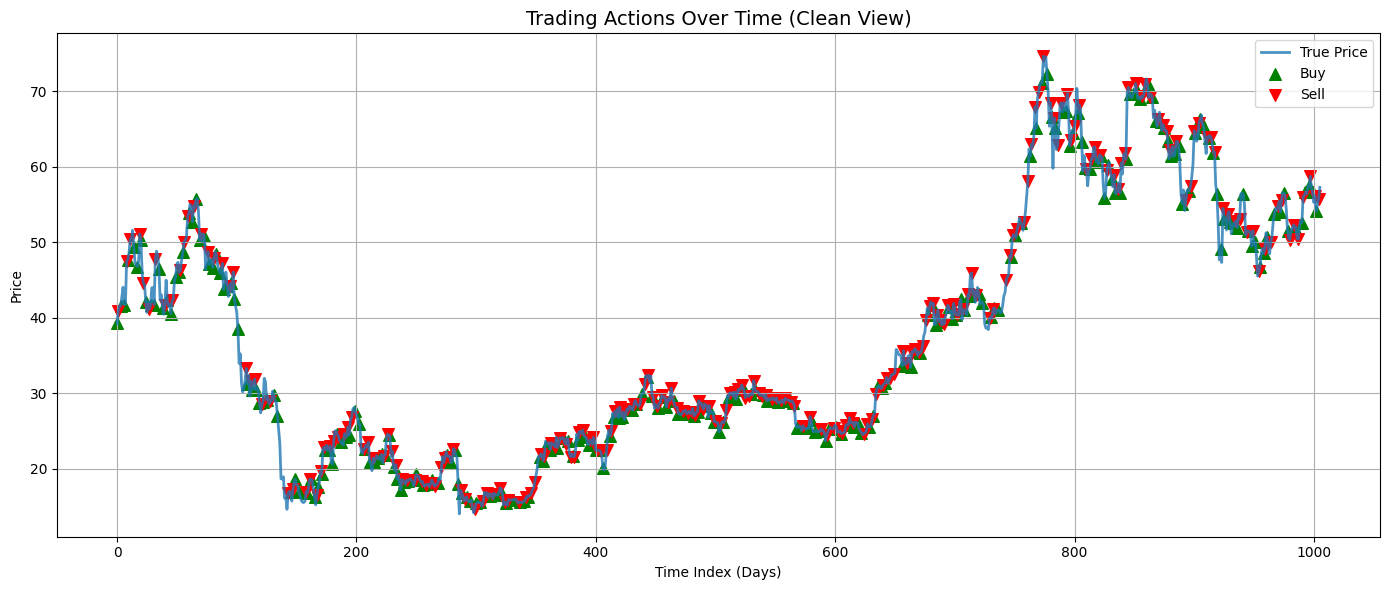

In [316]:
import matplotlib.pyplot as plt

# Only keep significant signals (e.g., at least 3-day gap)
def filter_signals(indices, min_gap=3):
    filtered = []
    last_idx = -min_gap
    for idx in indices:
        if idx - last_idx >= min_gap:
            filtered.append(idx)
            last_idx = idx
    return filtered

# Extract raw actions
actions = [x[0] for x in history]
portfolio_values = [x[3] for x in history]
prices = gbm_true[:len(history)]

# Filter signals to declutter
buy_signals = filter_signals([i for i, a in enumerate(actions) if a == "Buy"])
sell_signals = filter_signals([i for i, a in enumerate(actions) if a == "Sell"])

# Plot price + actions
plt.figure(figsize=(14, 6))
plt.plot(prices, label='True Price', linewidth=2, alpha=0.8)
plt.scatter(buy_signals, [prices[i] for i in buy_signals], label='Buy', marker='^', color='green', s=70)
plt.scatter(sell_signals, [prices[i] for i in sell_signals], label='Sell', marker='v', color='red', s=70)

plt.title("Trading Actions Over Time (Clean View)", fontsize=14)
plt.xlabel("Time Index (Days)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# TASK 2


In [390]:
import pandas as pd
import numpy as np

def simulate_trading_with_leverage(preds, actuals, transaction_fee=0.01):
    # Initial portfolio
    cash = 10000.0
    crypto = 100
    action_streak = 0
    last_action = None
    history = []
    realized_pnl = 0
    total_units_bought = 100
    total_cost_basis = 100 * actuals[0]  # Initial cost basis

    # Action counters
    buy_count = 0
    sell_count = 0
    hold_count = 0

    for i in range(len(preds) - 1):
        current_price = actuals[i]
        predicted_next = preds[i]
        actual_next = actuals[i + 1]

        # === Determine action (with leverage rule) ===
        if predicted_next > current_price * 1.0001:
            action = "Buy"
            quantity = 2 if predicted_next > current_price * 1.0002 else 1  # Use 2 units if strong uptrend
            buy_count += quantity
        elif predicted_next < current_price * 0.9999:
            action = "Sell"
            quantity = 2 if predicted_next < current_price * 0.9998 else 1  # Use 2 units if strong downtrend
            sell_count += quantity
        else:
            action = "Hold"
            quantity = 0
            hold_count += 1

        # === Enforce 5-action streak rule ===
        if action == last_action:
            action_streak += 1
        else:
            action_streak = 1
            last_action = action

        if action_streak > 5:
            action = "Hold"
            quantity = 0
            hold_count += 1

        # === Apply action ===
        if action == "Buy" and cash >= quantity * current_price * (1 + transaction_fee):
            # Buy units (including transaction fee)
            buy_cost = quantity * current_price * (1 + transaction_fee)
            cash -= buy_cost
            crypto += quantity
            # Update cost basis
            total_cost_basis += buy_cost
            total_units_bought += quantity
        
        elif action == "Sell" and crypto >= quantity:
            # Sell units (after transaction fee)
            sell_revenue = quantity * current_price * (1 - transaction_fee)
            # Average cost per unit
            average_cost_per_unit = total_cost_basis / total_units_bought
            # Realized P&L for this sale
            profit_per_unit = sell_revenue / quantity - average_cost_per_unit
            realized_pnl += profit_per_unit * quantity
            # Update cost basis (only reduce by the average cost of the sold units)
            total_cost_basis -= average_cost_per_unit * quantity
            total_units_bought -= quantity
            # Update cash and crypto holdings
            cash += sell_revenue
            crypto -= quantity

        # Record portfolio value
        portfolio_value = cash + crypto * actual_next
        history.append((action, cash, crypto, portfolio_value, realized_pnl))

    # Print action counts
    total_actions = buy_count + sell_count + hold_count
    print(f"Total Actions: {total_actions}")
    print(f"Total Buys: {buy_count}")
    print(f"Total Sells: {sell_count}")
    print(f"Total Holds: {hold_count}")

    return history


In [391]:
def calculate_metrics_with_leverage(history, actuals, starting_cash=10000.0, starting_crypto=100):
    # Initialize P&L and action counters
    realized_pnl = 0
    buy_count = 0
    sell_count = 0
    previous_cash = starting_cash
    crypto_units = starting_crypto
    cost_basis = starting_crypto * actuals[0]  # Initial crypto cost

    # Process each action
    for action, cash, crypto, portfolio, pnl in history:
        if action == "Buy":
            buy_count += 1
        elif action == "Sell":
            sell_count += 1
            realized_pnl = pnl

        # Update the previous cash balance
        previous_cash = cash

    # Calculate final portfolio value
    final_cash = history[-1][1]
    final_crypto = history[-1][2]
    final_price = actuals[-1]
    final_value = final_cash + final_crypto * final_price

    # Total actions
    total_actions = buy_count + sell_count

    # Print results
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Cash: ${final_cash:.2f}")
    print(f"Crypto Units: {final_crypto}")
    print(f"Accumulated Realized P&L: ${realized_pnl:.2f}")
    # print(f"Total Actions: {total_actions}")
    # print(f"Total Buys: {buy_count}")
    # print(f"Total Sells: {sell_count}")

    # Return as a dictionary for further analysis
    return {
        "Final Portfolio Value": final_value,
        "Cash": final_cash,
        "Crypto Units": final_crypto,
        "Accumulated Realized P&L": realized_pnl,
        "Total Actions": total_actions,
        "Total Buys": buy_count,
        "Total Sells": sell_count
    }

## rf

In [393]:
# Run the leveraged simulation
history_leverage = simulate_trading_with_leverage(rf_predictions, gbm_true)

# Calculate metrics
metrics = calculate_metrics_with_leverage(history_leverage, gbm_true)

Total Actions: 2145
Total Buys: 964
Total Sells: 1044
Total Holds: 137
Final Portfolio Value: $15424.73
Cash: $10900.76
Crypto Units: 76
Accumulated Realized P&L: $1197.85


## xgb

In [394]:
# Run the leveraged simulation
history_leverage = simulate_trading_with_leverage(xgb_predictions, gbm_true)

# Calculate metrics
metrics = calculate_metrics_with_leverage(history_leverage, gbm_true)

Total Actions: 2070
Total Buys: 1024
Total Sells: 987
Total Holds: 59
Final Portfolio Value: $16866.00
Cash: $9306.19
Crypto Units: 127
Accumulated Realized P&L: $2377.47


## mlp

In [395]:
# Run the leveraged simulation
history_leverage = simulate_trading_with_leverage(mlp_predictions, gbm_true)

# Calculate metrics
metrics = calculate_metrics_with_leverage(history_leverage, gbm_true)

Total Actions: 2092
Total Buys: 1284
Total Sells: 722
Total Holds: 86
Final Portfolio Value: $24880.91
Cash: $356.19
Crypto Units: 412
Accumulated Realized P&L: $3437.80


## rnn

In [396]:
# Run the leveraged simulation
history_leverage = simulate_trading_with_leverage(rnn_preds, gbm_true)

# Calculate metrics
metrics = calculate_metrics_with_leverage(history_leverage, gbm_true)

Total Actions: 2176
Total Buys: 984
Total Sells: 1019
Total Holds: 173
Final Portfolio Value: $16704.42
Cash: $10394.66
Crypto Units: 106
Accumulated Realized P&L: $2068.33


## ensemble

In [397]:
# Run the leveraged simulation
history_leverage = simulate_trading_with_leverage(ensemble_predictions, gbm_true)

# Calculate metrics
metrics = calculate_metrics_with_leverage(history_leverage, gbm_true)


Total Actions: 2069
Total Buys: 1190
Total Sells: 818
Total Holds: 61
Final Portfolio Value: $23756.70
Cash: $422.51
Crypto Units: 392
Accumulated Realized P&L: $4270.31


## graph

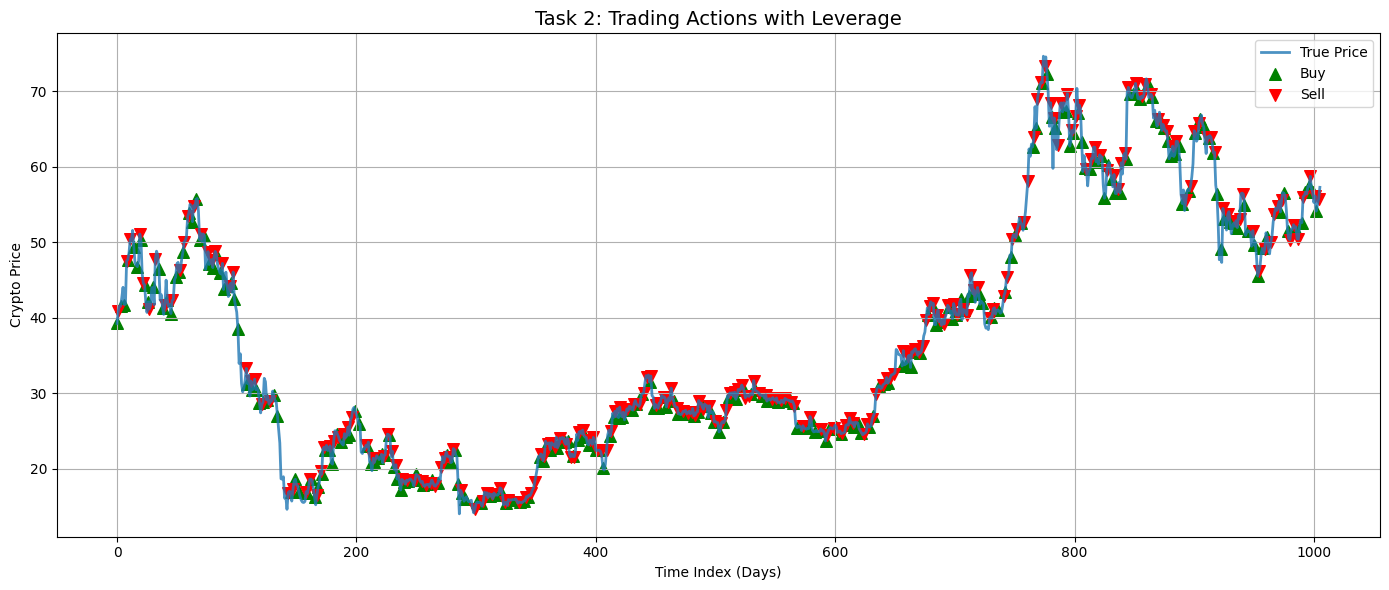

In [398]:
import matplotlib.pyplot as plt

# Function to filter signals
def filter_signals(indices, min_gap=3):
    filtered = []
    last_idx = -min_gap
    for idx in indices:
        if idx - last_idx >= min_gap:
            filtered.append(idx)
            last_idx = idx
    return filtered

# Extract data
actions = [x[0] for x in history_leverage]
portfolio_values = [x[4] for x in history_leverage]  # Portfolio value
prices = gbm_true[:len(history_leverage)]  # Price series aligned

# Filter buy/sell signals
buy_signals = filter_signals([i for i, a in enumerate(actions) if a == "Buy"])
sell_signals = filter_signals([i for i, a in enumerate(actions) if a == "Sell"])

# Plot price + buy/sell actions
plt.figure(figsize=(14, 6))
plt.plot(prices, label='True Price', linewidth=2, alpha=0.8)
plt.scatter(buy_signals, [prices[i] for i in buy_signals], label='Buy', marker='^', color='green', s=70)
plt.scatter(sell_signals, [prices[i] for i in sell_signals], label='Sell', marker='v', color='red', s=70)

plt.title("Task 2: Trading Actions with Leverage", fontsize=14)
plt.xlabel("Time Index (Days)")
plt.ylabel("Crypto Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
